In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
plt.style.use("seaborn-v0_8")

In [2]:
prices_raw_neg_1 = pd.read_csv("prices_round_2_day_-1.csv", sep = ";", index_col = "timestamp")
prices_raw_0 = pd.read_csv("prices_round_2_day_0.csv", sep = ";", index_col = "timestamp")

In [3]:
prices_raw_0.index = prices_raw_0.index + prices_raw_neg_1.index.max() + 100
prices_raw_0

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
1000000,0,ASH_COATED_OSMIUM,9995.0,13.0,9992.0,21.0,NaN,NaN,10011.0,13.0,10013.0,21.0,NaN,NaN,10003.0,0.0
1000000,0,INTARIAN_PEPPER_ROOT,11991.0,25.0,NaN,NaN,NaN,NaN,12006.0,9.0,12009.0,25.0,NaN,NaN,11998.5,0.0
1000100,0,INTARIAN_PEPPER_ROOT,11991.0,22.0,NaN,NaN,NaN,NaN,12007.0,8.0,12010.0,22.0,NaN,NaN,11999.0,0.0
1000100,0,ASH_COATED_OSMIUM,9995.0,15.0,9992.0,26.0,NaN,NaN,10011.0,15.0,10013.0,26.0,NaN,NaN,10003.0,0.0
1000200,0,INTARIAN_PEPPER_ROOT,11994.0,9.0,11991.0,22.0,NaN,NaN,12010.0,22.0,NaN,NaN,NaN,NaN,12002.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999700,0,INTARIAN_PEPPER_ROOT,12993.0,11.0,NaN,NaN,NaN,NaN,13007.0,11.0,13010.0,23.0,NaN,NaN,13000.0,0.0
1999800,0,INTARIAN_PEPPER_ROOT,12993.0,9.0,12990.0,24.0,NaN,NaN,13007.0,9.0,13010.0,24.0,NaN,NaN,13000.0,0.0
1999800,0,ASH_COATED_OSMIUM,10000.0,10.0,9997.0,27.0,NaN,NaN,10016.0,10.0,10018.0,27.0,NaN,NaN,10008.0,0.0


In [4]:
prices_raw = pd.concat([prices_raw_neg_1, prices_raw_0], axis=0)
prices_raw

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,-1,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
0,-1,ASH_COATED_OSMIUM,9982.0,21.0,NaN,NaN,NaN,NaN,10000.0,13.0,10003.0,21.0,NaN,NaN,9991.0,0.0
100,-1,ASH_COATED_OSMIUM,9984.0,15.0,NaN,NaN,NaN,NaN,10000.0,15.0,10003.0,26.0,NaN,NaN,9992.0,0.0
100,-1,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
200,-1,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,30.0,NaN,NaN,10001.0,15.0,NaN,NaN,NaN,NaN,9993.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999700,0,INTARIAN_PEPPER_ROOT,12993.0,11.0,NaN,NaN,NaN,NaN,13007.0,11.0,13010.0,23.0,NaN,NaN,13000.0,0.0
1999800,0,INTARIAN_PEPPER_ROOT,12993.0,9.0,12990.0,24.0,NaN,NaN,13007.0,9.0,13010.0,24.0,NaN,NaN,13000.0,0.0
1999800,0,ASH_COATED_OSMIUM,10000.0,10.0,9997.0,27.0,NaN,NaN,10016.0,10.0,10018.0,27.0,NaN,NaN,10008.0,0.0


In [5]:
aco = prices_raw[prices_raw["product"] != "ASH_COATED_OSMIUM"]
aco

,day,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
timestamp,,,,,,,,,,,,,,,,
0,-1,INTARIAN_PEPPER_ROOT,10994.0,9.0,NaN,NaN,NaN,NaN,11009.0,25.0,NaN,NaN,NaN,NaN,11001.5,0.0
100,-1,INTARIAN_PEPPER_ROOT,10994.0,8.0,10991.0,22.0,NaN,NaN,11006.0,8.0,11009.0,22.0,NaN,NaN,11000.0,0.0
200,-1,INTARIAN_PEPPER_ROOT,NaN,NaN,NaN,NaN,NaN,NaN,11006.0,9.0,11009.0,22.0,NaN,NaN,11006.0,0.0
300,-1,INTARIAN_PEPPER_ROOT,10994.0,8.0,NaN,NaN,NaN,NaN,11009.0,23.0,NaN,NaN,NaN,NaN,11001.5,0.0
400,-1,INTARIAN_PEPPER_ROOT,10994.0,10.0,10992.0,15.0,NaN,NaN,11006.0,10.0,11009.0,15.0,NaN,NaN,11000.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999500,0,INTARIAN_PEPPER_ROOT,12993.0,9.0,12989.0,24.0,NaN,NaN,13006.0,9.0,13010.0,24.0,NaN,NaN,12999.5,0.0
1999600,0,INTARIAN_PEPPER_ROOT,12993.0,12.0,12989.0,23.0,NaN,NaN,13007.0,12.0,NaN,NaN,NaN,NaN,13000.0,0.0
1999700,0,INTARIAN_PEPPER_ROOT,12993.0,11.0,NaN,NaN,NaN,NaN,13007.0,11.0,13010.0,23.0,NaN,NaN,13000.0,0.0


In [6]:
aco = aco.copy()
aco["mid_price"] = aco["mid_price"].replace(0, np.nan).ffill()

In [7]:
print(aco.ask_price_1.mean())
print(aco.mid_price.mean())
print(aco.bid_price_1.std())
print(aco.bid_price_1.mean())

12007.892431729519
11999.937925
576.9592037040281
11992.797918834547


In [8]:
n_std = 2
upper_band = 10000 + n_std * aco.mid_price.std()
lower_band = 10000 - n_std * aco.mid_price.std()

In [9]:
aco["SMA"] = aco.mid_price.rolling(20).mean()

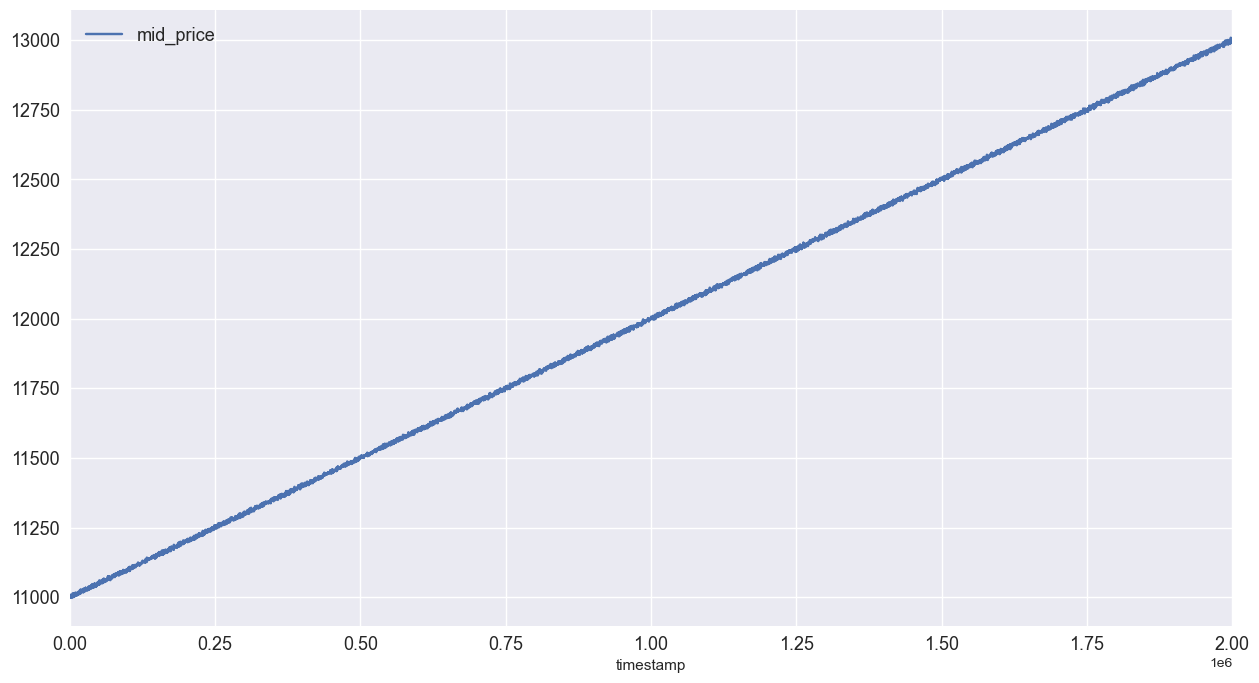

In [12]:
start = 0
window = 2000000
range = [start, start + window]
y_spread = 20

# aco[["ask_price_1", "bid_price_1"]].plot(figsize = (15, 8), fontsize = 13, xlim=(range[0], range[1]), ylim=(10000 - y_spread, 10000 + y_spread))
aco["mid_price"].plot(figsize = (15, 8), fontsize = 13, xlim=(range[0], range[1]))
plt.legend(fontsize = 13)
plt.show()